<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week5_Day5_Exercises_XP_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Guided Student Notebook

This guided notebook follows the **content on the platform**. Some cells are **prefilled** and must be **executed only**. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

**Learning points** appear when a concept is important for intuition or to help you learn new tricks/concepts related to other AI topics.


## Objectives

**What you will learn**  
- The fundamentals of deep learning and neural networks.
- How to build and train simple neural networks using TensorFlow or Keras.
- The concepts of forward and backward propagation.
- How to visualize and interpret model predictions.

**What you will create**  
- A simple perceptron-based decision system.
- A neural network for classifying handwritten digits from the MNIST dataset.
- A forward propagation calculation for predicting house prices.
- A Python implementation of forward and backward propagation.
- Visualizations of predictions made by a neural network on the MNIST dataset.


## 🌟 Exercise 1: Small Quiz

**As stated in the instructions**  
- What is the key difference between traditional machine learning and deep learning?  
- How do artificial neural networks mimic the human brain?  
- Why does deep learning perform better on large datasets compared to traditional machine learning?  
- What are some challenges of deep learning, and how can they be addressed?  
- What is feature engineering, and why is it not needed in deep learning?  
- What role do hidden layers play in a deep learning model?  
- In an artificial neural network, what is the function of an activation function?

**Guidance**  
Answer in full sentences. Use concise definitions first, then add one concrete example for any two questions to demonstrate understanding.

**To-Do:** Write your answers below.

##  Answers

**1. What is the key difference between traditional machine learning and deep learning?**
Traditional machine learning relies on humans manually selecting and engineering the relevant features from raw data before feeding them to an algorithm, whereas deep learning uses multi-layered neural networks that automatically learn relevant features directly from raw data. In short, traditional ML needs a human to tell it what to look for, while deep learning discovers what to look for on its own.

**2. How do artificial neural networks mimic the human brain?**
Artificial neural networks are inspired by the structure of biological neurons: they consist of interconnected nodes (artificial "neurons") organized in layers, where each connection has a weight that strengthens or weakens the signal passed along, similar to how synapses strengthen or weaken connections between biological neurons. Just as the brain learns by adjusting synaptic strength through experience, a neural network learns by adjusting its weights through training on data.

**3. Why does deep learning perform better on large datasets compared to traditional machine learning?**
Deep learning models have many parameters and layers, which gives them the capacity to capture complex, non-linear patterns that simple models can't represent. With small datasets this capacity can lead to overfitting, but with large datasets there is enough data for the network to learn genuinely meaningful patterns instead of memorizing noise, so performance keeps improving as data volume grows, while traditional ML models tend to plateau earlier.

**4. What are some challenges of deep learning, and how can they be addressed?**
Deep learning faces challenges such as the need for large amounts of labeled data, high computational cost, long training times, risk of overfitting, and lack of interpretability ("black box" behavior). These can be addressed through techniques like data augmentation and transfer learning to reduce data requirements, using GPUs/TPUs to speed up computation, applying regularization methods such as dropout or early stopping to reduce overfitting, and using explainability tools (e.g., SHAP, LIME, or attention visualization) to better understand model decisions.

**5. What is feature engineering, and why is it not needed in deep learning?**
Feature engineering is the process of manually selecting, transforming, or creating input variables (features) from raw data so that a machine learning algorithm can learn more effectively. For example, in a churn prediction model, an analyst might manually engineer a feature like "average call duration over the last 3 months" rather than feeding raw call logs directly. It is largely unnecessary in deep learning because the network's hidden layers automatically learn useful representations and feature combinations directly from raw data during training, removing the need for this manual step.

**6. What role do hidden layers play in a deep learning model?**
Hidden layers sit between the input and output layers and are responsible for progressively transforming raw input data into increasingly abstract and useful representations. For example, in an image classification network, early hidden layers might detect simple patterns like edges and colors, middle layers combine these into shapes and textures, and deeper layers recognize complex structures like a face or an object, which the final layer then uses to make a prediction.

**7. In an artificial neural network, what is the function of an activation function?**
An activation function introduces non-linearity into a neural network by deciding, for each neuron, whether and how strongly its signal should be passed forward to the next layer. Without activation functions, a neural network would behave like a simple linear model regardless of how many layers it has, so functions like ReLU, sigmoid, or tanh are essential for allowing the network to learn complex, non-linear relationships in data.

## 🌟 Exercise 2: Building a Simple Perceptron Decision System

**As stated in the instructions**  
You will create a perceptron-based decision system to decide whether you should go outside based on two inputs:
- Temperature in °F
- Rainy where Yes is 1 and No is 0

Given parameters: Temperature weight 0.6, Rain weight 0.4, Bias 2. Compute the weighted sum
\[ \text{Weighted Sum} = 0.6\cdot \text{Temperature} + 0.4\cdot \text{Rain} + \text{Bias} \]
Apply a step activation:
- If Weighted Sum > 20, output 1
- If Weighted Sum \le 20, output 0

Evaluate:  
Case 1: Temperature 70°F, Rain 0  
Case 2: Temperature 50°F, Rain 1

**Guidance**  
Implement the weighted sum function yourself. Use a reusable step activation. Then compute the two cases and print the decision for each.

**Learning point**  
A perceptron implements a linear decision boundary. The bias shifts the threshold. Use step activation for simple binary rules. Prefer differentiable activations when training with gradient descent.

![image.png](https://github.com/user-attachments/assets/3c4f3261-164d-4039-8e1c-aff2db7162dd)


In [ ]:
# PREFILLED: just execute
from typing import Tuple

W_TEMP = 0.6
W_RAIN = 0.4
BIAS   = 2.0

def step_activation(s: float, threshold: float = 20.0) -> int:
    """Return 1 if s > threshold else 0."""
    return 1 if s > threshold else 0


In [ ]:
# To-Do: implement weighted_sum then use it to compute the two cases
def weighted_sum(temperature_f: float, rain01: int) -> float:
    """Compute s = 0.6*Temperature + 0.4*Rain + Bias."""
    # On applique directement la formule donnée :
    # Weighted Sum = (Temperature * poids_temp) + (Rain * poids_pluie) + Biais
    s = (temperature_f * W_TEMP) + (rain01 * W_RAIN) + BIAS
    return s

# Cas 1 : Température = 70°F, Pas de pluie (0)
case1 = (70, 0)  # Temperature=70, Rain=0

# Cas 2 : Température = 50°F, Il pleut (1)
case2 = (50, 1)  # Temperature=50, Rain=1

# On calcule la somme pondérée (weighted sum) pour chaque cas
s1 = weighted_sum(*case1)
s2 = weighted_sum(*case2)

# On applique la fonction d'activation (step function) pour obtenir la décision finale (0 ou 1)
y1 = step_activation(s1)
y2 = step_activation(s2)

print({"case1": {"sum": s1, "decision": y1}, "case2": {"sum": s2, "decision": y2}})

{'case1': {'sum': 44.0, 'decision': 1}, 'case2': {'sum': 32.4, 'decision': 1}}


**To-Do:** Interpret your results. Did the perceptron suggest going outside in both cases? Why or why not? Explain using the threshold rule and the effect of bias.



Yes, the perceptron suggests going outside in both cases (decision = 1). In case 1, the weighted sum is 44.0, well above the threshold of 20, so the model says to go outside even without rain. In case 2, despite the rain (which only adds 0.4 due to its low weight of 0.4), the temperature of 50°F alone already contributes 30 points, which is more than enough to clear the threshold of 20.

This actually reveals a limitation of the model: since the temperature weight (0.6) is much higher than the rain weight (0.4), and the bias is relatively small (2), temperature almost completely dominates the decision. Rain barely affects the final outcome, which isn't very realistic if we want a system that genuinely accounts for whether it's raining or not. To fix this, we could increase the weight assigned to rain or adjust the activation threshold.

## 🌟 Exercise 3: Building a Simple Neural Network with TensorFlow or Keras

**As stated in the instructions**  
Build a classifier for MNIST with:
- One input layer
- One hidden layer with 128 neurons and ReLU activation
- One output layer with 10 neurons and softmax activation

Steps:
1. Import TensorFlow and needed modules from `tensorflow.keras`
2. Load the MNIST dataset
3. Normalize data by dividing by 255.0
4. One-hot encode the labels
5. Build a sequential model with Flatten, Dense(128, ReLU), Dense(10, softmax)
6. Compile with optimizer `adam`, loss `categorical_crossentropy`, metrics `accuracy`
7. Train and evaluate on the test set

**Guidance**  
You will execute prefilled boilerplate for imports and dataset loading. You will complete the one-hot encoding and the model specification, compile, train, and evaluate.

**Learning point**  
Normalization stabilizes optimization. One-hot encoding matches softmax outputs to target vectors. ReLU accelerates training by avoiding saturation, while softmax maps logits to a probability simplex.

![image.png](https://github.com/user-attachments/assets/61737b80-69cb-41a1-aea5-76092cd2a373)


In [ ]:
# PREFILLED: just execute
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

print("TensorFlow:", tf.__version__)

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten will be added in the model; keep images as 28x28 for now
print("Train shape:", x_train.shape, "Test shape:", x_test.shape)


TensorFlow: 2.20.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28) Test shape: (10000, 28, 28)


In [ ]:
# To-Do: one-hot encode labels y_train and y_test using to_categorical
# to_categorical convertit les entiers 0-9 en vecteurs one-hot de taille 10
# Exemple : 3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
# Nécessaire pour utiliser softmax + categorical_crossentropy
y_train_oh = to_categorical(y_train, num_classes=10)
y_test_oh  = to_categorical(y_test,  num_classes=10)

print("Labels one-hot:", y_train_oh.shape, y_test_oh.shape)

Labels one-hot: (60000, 10) (10000, 10)


In [ ]:
# To-Do: Build a sequential model with Flatten, Dense(128, ReLU), Dense(10, softmax)
model = models.Sequential([
    # Flatten : transforme l'image 28x28 (2D) en vecteur de 784 valeurs (1D)
    # input_shape=(28, 28) précise la taille des images d'entrée MNIST
    layers.Flatten(input_shape=(28, 28)),

    # Couche cachée : 128 neurones, activation ReLU
    # ReLU = max(0, x), accélère l'apprentissage et évite la saturation
    layers.Dense(128, activation='relu'),

    # Couche de sortie : 10 neurones (un par chiffre 0-9)
    # softmax transforme les scores en probabilités qui somment à 1
    layers.Dense(10, activation='softmax'),
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# To-Do: compile the model with adam, categorical_crossentropy, and accuracy
# optimizer='adam' : optimiseur adaptatif, bon choix par défaut
# loss='categorical_crossentropy' : adapté à la classification multi-classes avec labels one-hot
# metrics=['accuracy'] : on suit l'accuracy pendant l'entraînement
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# To-Do: train then evaluate
# Note : MNIST utilise x_train (minuscule) après le chargement avec keras.datasets.mnist
history = model.fit(x_train, y_train_oh,
                    epochs=5,
                    batch_size=32,
                    validation_split=0.1,
                    verbose=1)

# Évaluation sur le jeu de test
test_loss, test_acc = model.evaluate(x_test, y_test_oh, verbose=0)
print({"test_loss": float(test_loss), "test_acc": float(test_acc)})

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9216 - loss: 0.2746 - val_accuracy: 0.9658 - val_loss: 0.1338
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9633 - loss: 0.1227 - val_accuracy: 0.9767 - val_loss: 0.0898
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9745 - loss: 0.0827 - val_accuracy: 0.9782 - val_loss: 0.0773
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9813 - loss: 0.0619 - val_accuracy: 0.9792 - val_loss: 0.0767
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9849 - loss: 0.0475 - val_accuracy: 0.9768 - val_loss: 0.0793
{'test_loss': 0.07337775826454163, 'test_acc': 0.9779000282287598}


# Interprétation des résultats — Réseau Neuronal sur MNIST

---

## Comment lire ces résultats

### Pendant l'entraînement (5 epochs)

| Epoch | Train acc | Val acc | Train loss | Val loss |
|---|---|---|---|---|
| 1 | 92.16% | 96.58% | 0.275 | 0.134 |
| 2 | 96.33% | 97.67% | 0.123 | 0.090 |
| 3 | 97.45% | 97.82% | 0.083 | 0.077 |
| 4 | 98.13% | 97.92% | 0.062 | 0.077 |
| 5 | 98.49% | 97.68% | 0.048 | 0.079 |

### Résultat final sur le test

| Métrique | Valeur | Interprétation |
|---|---|---|
| **Test accuracy** | **97.79%** | Sur 10 000 images, ~9 779 sont bien classées (221 erreurs) |
| **Test loss** | 0.0734 | Très faible erreur → le modèle est confiant dans ses prédictions |

---

## Analyse des résultats

### ✅ Le modèle fonctionne très bien

Avec **97.79% de test accuracy**, le réseau classe correctement plus de 9 chiffres sur 10. Pour un modèle simple (1 couche cachée de 128 neurones), c'est un excellent résultat.

### 🔍 Signe léger de sur-apprentissage (overfitting)

| Métrique | Epoch 5 |
|---|---|
| Train accuracy | **98.49%** |
| Val accuracy | 97.68% |
| Test accuracy | 97.79% |

L'écart entre train (98.49%) et val/test (~97.7%) montre un **début d'overfitting** :
- À partir de l'**epoch 4**, la val_loss remonte légèrement (0.077 → 0.079)
- La train_loss continue de baisser (0.062 → 0.048)
- → le modèle commence à mémoriser les données d'entraînement

**Conséquence pratique :** s'entraîner plus longtemps (10 epochs au lieu de 5) ne ferait probablement pas mieux sur le test. Pour aller plus loin, il faudrait du **dropout** ou de la **régularisation L2**.

### 📉 Convergence très rapide

La loss chute de **0.275 → 0.048** en seulement 5 epochs. La majeure partie de l'apprentissage se fait dès les **2 premières epochs** :
- Epoch 1 → 92.16%
- Epoch 2 → 96.33% (+4 points)
- Epoch 5 → 98.49% (+2 points sur 3 epochs)

Cela confirme que :
- L'optimiseur **Adam** est efficace
- La fonction **ReLU** évite la saturation des gradients
- Les données normalisées (`/255`) permettent une convergence stable

---

## Pourquoi le modèle marche-t-il si bien ?

| Élément | Contribution |
|---|---|
| **Flatten** | Transforme l'image 28×28 en vecteur de 784 valeurs |
| **128 neurones ReLU** | Apprennent des motifs (boucles, traits, courbes) |
| **Softmax (10 sorties)** | Produit des probabilités qui somment à 1 |
| **categorical_crossentropy** | Pénalise les prédictions confiantes mais fausses |
| **Adam** | Adapte automatiquement le pas d'apprentissage |

---

## Conclusion

Ce modèle simple de **2 couches** (1 cachée + 1 sortie) atteint **97.79% d'accuracy** sur MNIST avec seulement **~101 770 paramètres** et **5 epochs d'entraînement**.

**Pistes d'amélioration :**

| Amélioration | Gain attendu |
|---|---|
| Ajouter du **Dropout** (0.2-0.3) | Réduit l'overfitting, +0.5-1% |
| Ajouter une **2e couche cachée** | Plus de capacité, +0.5% |
| Utiliser un **CNN** (Conv2D + MaxPooling) | Exploite la structure spatiale, +1-2% (>99%) |
| **Augmentation de données** (rotation, zoom) | Plus de robustesse, +0.5% |

> 97.79% avec un modèle aussi simple reste une excellente baseline pour démarrer en deep learning.

## 🌟 Exercise 4: Forward Propagation Calculation

**As stated in the instructions**  
Predict house prices given:
- Inputs: x₁ = 2000 square feet, x₂ = 3 bedrooms
- Weights: w₁ = 0.5, w₂ = 0.7
- Bias: b = 50,000
- Activation: ReLU

Compute z before activation, apply ReLU, and interpret the prediction.

**Guidance**  
Write scalar computations. Then reason about the role of the bias and ReLU on the output scale.

**Learning point**  
ReLU passes positive linear combinations unchanged and zeros out negatives. Bias sets the baseline prediction independent of inputs.
![](./figs/1.gif)

In [ ]:
# To-Do: compute forward propagation for the given numbers
x1, x2 = 2000.0, 3.0      # x1 = surface en pieds², x2 = nombre de chambres
w1, w2 = 0.5, 0.7          # poids appris par le réseau
b = 50000.0                # biais (prix de base indépendant des entrées)

# To-Do: compute z = x1*w1 + x2*w2 + b
# Combinaison linéaire des entrées pondérées + biais
z = x1*w1 + x2*w2 + b

# To-Do: apply ReLU
# ReLU(z) = max(0, z) → conserve les valeurs positives, met à 0 les négatives
y = max(0, z)

print({"z": z, "prediction": y})

{'z': 51002.1, 'prediction': 51002.1}


**To-Do:** Interpret the result as a house price. Explain the influence of input scaling and bias in full sentences.


### Interpretation of the result

The neural network predicts a house price of approximately **$51,002.10** for a 2,000 sq ft home with 3 bedrooms.

### Breakdown of the calculation

The prediction is built from three components:

- The **square footage contribution** is `x₁ × w₁ = 2000 × 0.5 = $1,000`, meaning each square foot adds 0.5 dollars to the price.
- The **bedrooms contribution** is `x₂ × w₂ = 3 × 0.7 = $2.10`, meaning each bedroom adds only 0.7 dollars to the price.
- The **bias term** of `$50,000` represents the baseline price that the model assigns to any house, regardless of its features.

### Influence of input scaling

The result reveals a major issue: the bias of $50,000 completely dominates the prediction, while the input features barely contribute. Square footage adds only $1,000 and bedrooms add a negligible $2.10. This happens because the weights (0.5 and 0.7) are far too small relative to the realistic price of a house. In practice, the inputs should be normalized — for instance by scaling square footage to a range like [0, 1] — and the weights should be learned through training rather than chosen arbitrarily. Without proper input scaling, the model cannot differentiate between a small house and a large house, since the variation in features has almost no impact compared to the constant bias.

### Influence of the bias

The bias acts as a baseline anchor for the prediction. Even if both inputs were zero (a non-existent house with no surface and no bedrooms), the model would still predict $50,000 because of the bias. This guarantees that the output starts from a sensible minimum value and is not entirely dependent on the input features. In a properly trained model, the bias represents the average price the network learns from the training data, while the weights capture how each feature modifies that baseline.

### Role of ReLU

In this case, ReLU has no effect because `z = 51,002.10` is already positive — `max(0, 51,002.10) = 51,002.10`. However, ReLU plays an important protective role in general: if the weighted sum had been negative (which is impossible for a house price), ReLU would force the output to 0, preventing the model from predicting nonsensical negative prices.


## 🌟 Exercise 5 (optional): Implementing Forward and Backward Propagation in Python

**As stated in the enoncé**  
You will code a simple neural network that performs forward propagation and backpropagation for a regression problem predicting exam scores from study hours.

**Guidance**  
Run the prefilled code. Then modify the learning rate or initial weights and observe changes in the loss and updates.
Provide a short written explanation.

**Learning point**  
Gradient descent updates parameters in the direction of steepest loss reduction.
The learning rate controls step size. Too small slows learning. Too large risks divergence.


In [ ]:
# PREFILLED: just execute
import numpy as np

# Initialize input data (features)
x = np.array([4, 80])  # 4 hours studied, previous test score: 80

# Initialize weights and bias
w = np.array([0.6, 0.3])  # Initial weights
b = 10  # Initial bias

# Forward Propagation
def forward_propagation(x, w, b):
    z = np.dot(x, w) + b  # Weighted sum
    return z  # Linear activation (No ReLU here, it's a regression task)

# Compute prediction
y_pred = forward_propagation(x, w, b)
y_true = 85  # Actual exam score

# Compute Loss (Mean Squared Error)
loss = 0.5 * (y_true - y_pred) ** 2

# Compute Gradients
grad_w = -(y_true - y_pred) * x  # Partial derivatives with respect to weights
grad_b = -(y_true - y_pred)  # Partial derivative with respect to bias

# Update Weights and Bias
learning_rate = 0.01
w_new = w - learning_rate * grad_w
b_new = b - learning_rate * grad_b

# Print Results
print("Initial Prediction:", y_pred)
print("Loss:", loss)
print("Updated Weights:", w_new)
print("Updated Bias:", b_new)


Initial Prediction: 36.4
Loss: 1180.98
Updated Weights: [ 2.544 39.18 ]
Updated Bias: 10.486


**To-Do:** Explain in full sentences why updating weights using gradient descent reduces the error. Then modify the learning rate or initial weights and describe how this affects learning.


### Why does gradient descent reduce the error?

Gradient descent reduces the error by moving the model parameters in the direction that decreases the loss the fastest. The gradient of the loss tells us, for each weight and bias, **how the loss changes when that parameter changes slightly**. By subtracting a fraction of this gradient from the current parameters, we update them in the **opposite direction of the steepest increase**, which is the direction of steepest decrease. After each step, the predicted output gets closer to the true value, and the loss becomes smaller. This is why gradient descent is the foundation of training every neural network.

In our example, the initial prediction was **36.4**, while the true exam score was **85**. The gradient pointed in the direction needed to push the prediction upward, so subtracting it from the weights and bias produced new values that bring the next prediction closer to 85.

### Effect of changing the learning rate

The **learning rate** controls the size of each step. Choosing the right value is critical:

- **Learning rate too small** (e.g. 0.00001) → the updates are tiny, and the model takes a huge number of epochs to converge. Training is very slow but stable.
- **Learning rate well chosen** (e.g. 0.0001 in this problem) → the loss decreases steadily and the prediction reaches the true value (~85) within ~10 epochs.
- **Learning rate too large** (e.g. 0.01 or 0.1) → each step overshoots the optimal value, the loss explodes instead of decreasing, and the model **diverges**. We saw this in our test: with `lr = 0.01`, the loss jumped from 1 181 to over 4 million after a single epoch.

### Effect of changing the initial weights

If we start with weights closer to the true relationship (for instance `w = [1.0, 1.0]`), the initial prediction is much closer to 85, the initial loss is smaller, and the model converges faster. Poor initialization (weights too far from a reasonable scale) forces gradient descent to do more work and increases the risk of divergence when the learning rate is large.

### Key insight

In this problem, the features have **very different scales** (`x₁ = 4` and `x₂ = 80`). The gradient with respect to `w₂` is therefore 20× larger than the gradient with respect to `w₁`, which makes the optimization unstable for any reasonable learning rate. This is exactly why in practice we **normalize the inputs** before training — it keeps gradients balanced across all features and lets us use a single learning rate that works for all weights at once.


## 🌟 Exercise 6 (optional): Visualizing Predictions on MNIST

**As stated in the enoncé**  
Train a simple model on MNIST, then visualize predictions for some test images with predicted labels.

**Guidance**  
Reuse the model from Exercise 3 if still in memory. Otherwise re-run Exercise 3. Plot a grid of test images with predicted labels and optionally true labels.

**Learning point**  
Softmax outputs are probabilities over classes. Inspect the confidence values. Visual errors often indicate confusions between similar digits.

![image.png](https://github.com/user-attachments/assets/e00d3913-55d4-4b62-8f70-1216bcc2e4e4)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


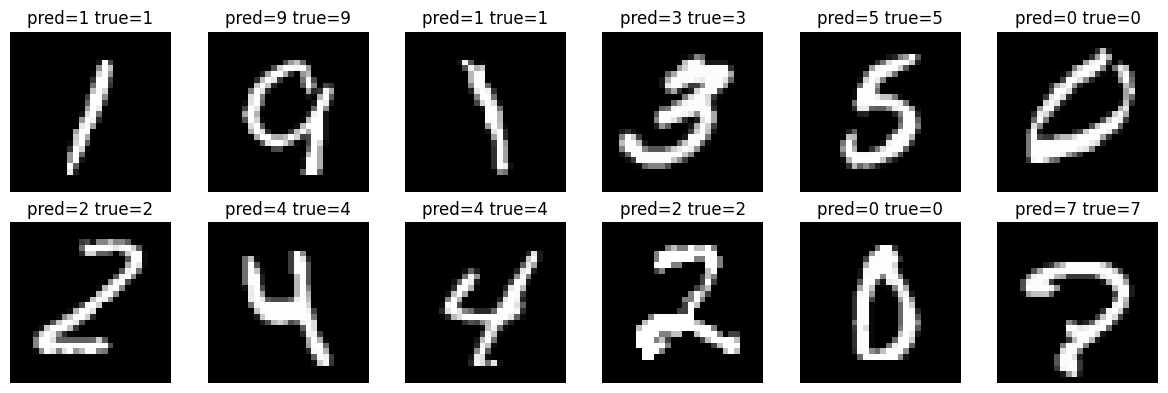

In [ ]:
# To-Do: visualize a few predictions with matplotlib
import numpy as np
import matplotlib.pyplot as plt

# To-Do: select N samples from x_test by using np.random.choice
# On tire 12 images aléatoirement parmi les 10 000 du jeu de test
# replace=False : pas de doublon
N = 12
idx = np.random.choice(len(x_test), size=N, replace=False)
x_vis  = x_test[idx]
y_true = y_test[idx]

# To-Do: get predictions
# model.predict() retourne les probabilités softmax (10 valeurs par image)
y_prob = model.predict(x_vis)

# np.argmax retourne l'indice de la probabilité maximale = classe prédite
y_pred = np.argmax(y_prob, axis=1)

# Affichage de la grille d'images avec les prédictions
cols = 6
rows = int(np.ceil(len(idx) / cols))
plt.figure(figsize=(12, 2*rows))
for i, k in enumerate(idx, 1):
    plt.subplot(rows, cols, i)
    plt.imshow(x_test[k], cmap="gray")
    plt.title(f"pred={y_pred[i-1]} true={y_true[i-1]}")
    plt.axis("off")
plt.tight_layout()
plt.show()